In [114]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict.csv
/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv


In [115]:
df = pd.read_csv('/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv')

In [116]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [117]:
df.shape

(500, 9)

In [118]:
# missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [119]:
# duplicated rows
df.duplicated().value_counts()

False    500
Name: count, dtype: int64

In [120]:
df.drop(columns = ['Serial No.'], inplace = True)

In [121]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [122]:
X = df.iloc[:, 0:-1]
Y = df.iloc[:, -1]

In [123]:
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [124]:
Y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance of Admit , Length: 500, dtype: float64

In [125]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 1)

In [126]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(400, 7) (100, 7) (400,) (100,)


In [127]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [128]:
X_train_scaled

array([[0.4       , 0.42857143, 0.5       , ..., 0.57142857, 0.50320513,
        0.        ],
       [0.56      , 0.64285714, 0.        , ..., 0.57142857, 0.55769231,
        1.        ],
       [0.2       , 0.32142857, 0.5       , ..., 0.28571429, 0.34615385,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.74038462,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.77884615,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.32051282,
        0.        ]])

In [129]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from keras.layers import Dense, Input

In [130]:
model = Sequential()
# Layer 0 Input Layer
model.add(Input(shape = (X_train_scaled.shape[1],)))
# Layer 1 Hidden Layer
model.add(Dense(16, activation = 'relu')) 
# Layer 2 Hidden Layer
model.add(Dense(8, activation = 'relu'))
# Layer 2 Output Layer
model.add(Dense(1, activation = 'linear')) # for regression activation function should be linear

In [131]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [132]:
# compile the model
model.compile(loss = 'mean_squared_error', optimizer = 'Adam')

In [133]:
# Training
history = model.fit(X_train_scaled, y_train, epochs = 40, validation_split = 0.2)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.3117 - val_loss: 1.2284
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0052 - val_loss: 0.9217
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7448 - val_loss: 0.6547
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4947 - val_loss: 0.3745
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2504 - val_loss: 0.1495
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0883 - val_loss: 0.0434
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0303 - val_loss: 0.0225
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0229 - val_loss: 0.0227
Epoch 9/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0221 - val_loss: 0.0202
Epoch 10/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0195 - val_loss: 0.0173
Epoch 11/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0178 - val_loss: 0.0161
Epoch 12/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0170 -

In [134]:
history.history

{'loss': [1.3117167949676514,
  1.0051509141921997,
  0.7448066473007202,
  0.4947119355201721,
  0.25039026141166687,
  0.08828161656856537,
  0.03030982054769993,
  0.02291192300617695,
  0.022102132439613342,
  0.01946345902979374,
  0.017772594466805458,
  0.01695134863257408,
  0.01639721356332302,
  0.015743646770715714,
  0.015034476295113564,
  0.01394379697740078,
  0.012471436522901058,
  0.01059555634856224,
  0.0093803396448493,
  0.0083848275244236,
  0.007576543837785721,
  0.006669039838016033,
  0.006224350072443485,
  0.006028149742633104,
  0.00594286760315299,
  0.005735273472964764,
  0.005556370597332716,
  0.0054041557013988495,
  0.005323883146047592,
  0.005262160673737526,
  0.005196483340114355,
  0.005078252404928207,
  0.004959496669471264,
  0.00489735696464777,
  0.004821387585252523,
  0.004716033115983009,
  0.004670507274568081,
  0.004655377008020878,
  0.0046279896050691605,
  0.004571457393467426],
 'val_loss': [1.2284350395202637,
  0.92173498868942

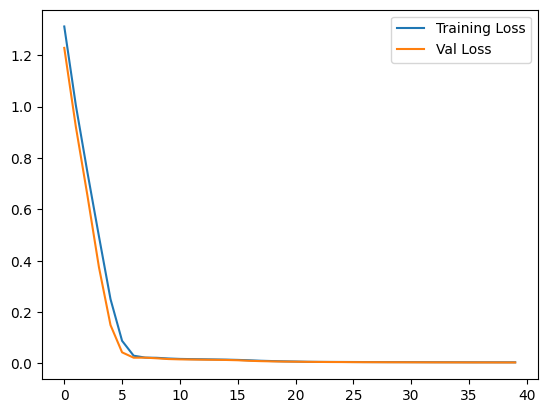

In [140]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.legend()
plt.show()

In [136]:
# Predictions
y_pred = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [137]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.780952359699474